In [1]:
import torch
import torch.nn as nn
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import os

from google.colab import drive
drive.mount('/content/drive')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando: {device}")

Mounted at /content/drive
Usando: cuda


In [2]:
from torchvision import datasets

data_dir  = '/content/drive/MyDrive/landmark_images'
train_dir = os.path.join(data_dir, 'train')

dataset    = datasets.ImageFolder(train_dir)
class_names = dataset.classes

print(f"Clases cargadas: {len(class_names)}")
print(class_names[:5])

Clases cargadas: 50
['00.Haleakala_National_Park', '01.Mount_Rainier_National_Park', '02.Ljubljana_Castle', '03.Dead_Sea', '04.Wroclaws_Dwarves']


In [3]:
# Reconstruir la arquitectura
model_tl = models.resnet18(weights=None)
num_features = model_tl.fc.in_features
model_tl.fc  = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, 50)
)

# Cargar los pesos desde Drive
model_tl.load_state_dict(torch.load(
    '/content/drive/MyDrive/landmark_images/best_model_tl.pth',
    map_location=device
))
model_tl = model_tl.to(device)
model_tl.eval()

print("Modelo cargado correctamente")

Modelo cargado correctamente


In [4]:
def predict_landmarks(img_path, k=5):
    # Transformación igual que en validación
    transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    # Cargar y transformar la imagen
    img        = Image.open(img_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0).to(device)

    # Predicción
    with torch.no_grad():
        outputs     = model_tl(img_tensor)
        probs       = torch.softmax(outputs, dim=1)
        top_probs, top_idxs = torch.topk(probs, k)

    # Mostrar imagen y resultados
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Imagen original
    axes[0].imshow(img)
    axes[0].axis('off')
    axes[0].set_title('Imagen de prueba', fontsize=12)

    # Top K predicciones
    labels = [class_names[i] for i in top_idxs[0].cpu().numpy()]
    probs_list = top_probs[0].cpu().numpy()

    axes[1].barh(range(k), probs_list, color='steelblue')
    axes[1].set_yticks(range(k))
    axes[1].set_yticklabels(labels, fontsize=9)
    axes[1].set_xlabel('Probabilidad')
    axes[1].set_title(f'Top {k} predicciones', fontsize=12)
    axes[1].invert_yaxis()

    plt.suptitle(f'Predicción: {labels[0]} ({probs_list[0]*100:.1f}%)', fontsize=13)
    plt.tight_layout()
    plt.show()

    return list(zip(labels, probs_list))

print("Función predict_landmarks lista")

Función predict_landmarks lista


In [5]:
# Copiar imágenes de Drive a Colab
import shutil

test_images_dir = '/content/drive/MyDrive/landmark_images/test_images'
dest_dir        = '/content/test_images'
os.makedirs(dest_dir, exist_ok=True)

for img_file in os.listdir(test_images_dir):
    shutil.copy(
        os.path.join(test_images_dir, img_file),
        os.path.join(dest_dir, img_file)
    )

print("Imágenes copiadas:")
print(os.listdir(dest_dir))

Imágenes copiadas:
['test1.jpg', 'test3.jpg', 'test4.jpg', 'test2.jpg']



=== test1.jpg ===


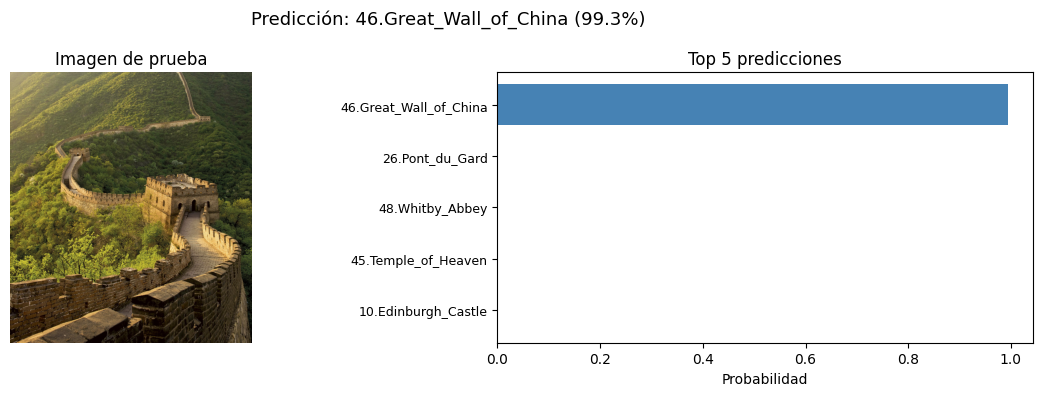

  Top 1: 46.Great_Wall_of_China (99.3%)
  Top 2: 26.Pont_du_Gard (0.1%)
  Top 3: 48.Whitby_Abbey (0.1%)
  Top 4: 45.Temple_of_Heaven (0.1%)
  Top 5: 10.Edinburgh_Castle (0.1%)

=== test2.jpg ===


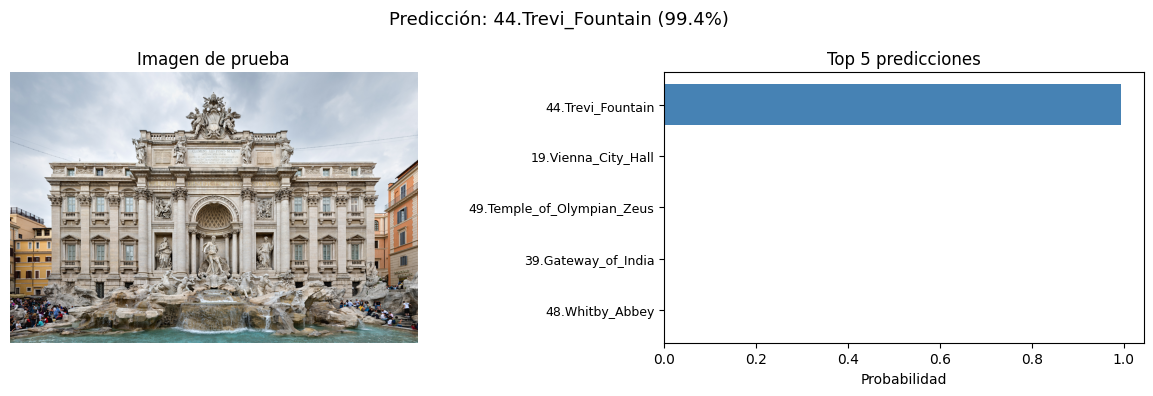

  Top 1: 44.Trevi_Fountain (99.4%)
  Top 2: 19.Vienna_City_Hall (0.2%)
  Top 3: 49.Temple_of_Olympian_Zeus (0.1%)
  Top 4: 39.Gateway_of_India (0.1%)
  Top 5: 48.Whitby_Abbey (0.1%)

=== test3.jpg ===


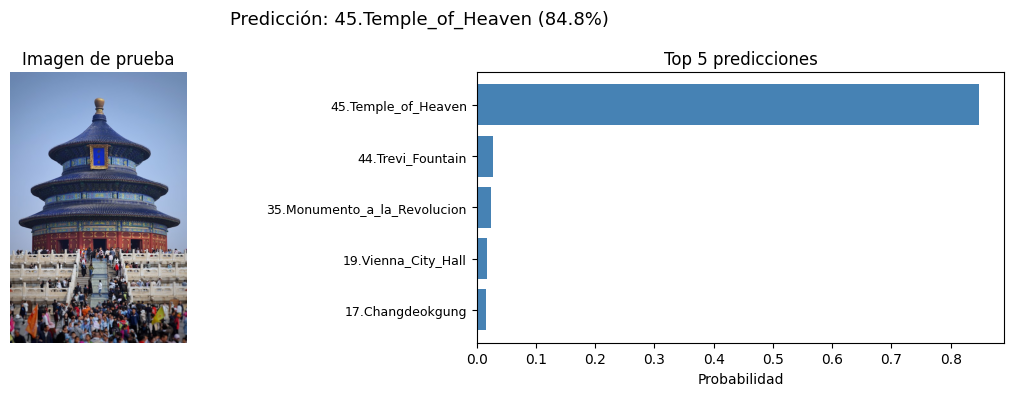

  Top 1: 45.Temple_of_Heaven (84.8%)
  Top 2: 44.Trevi_Fountain (2.8%)
  Top 3: 35.Monumento_a_la_Revolucion (2.4%)
  Top 4: 19.Vienna_City_Hall (1.8%)
  Top 5: 17.Changdeokgung (1.6%)

=== test4.jpg ===


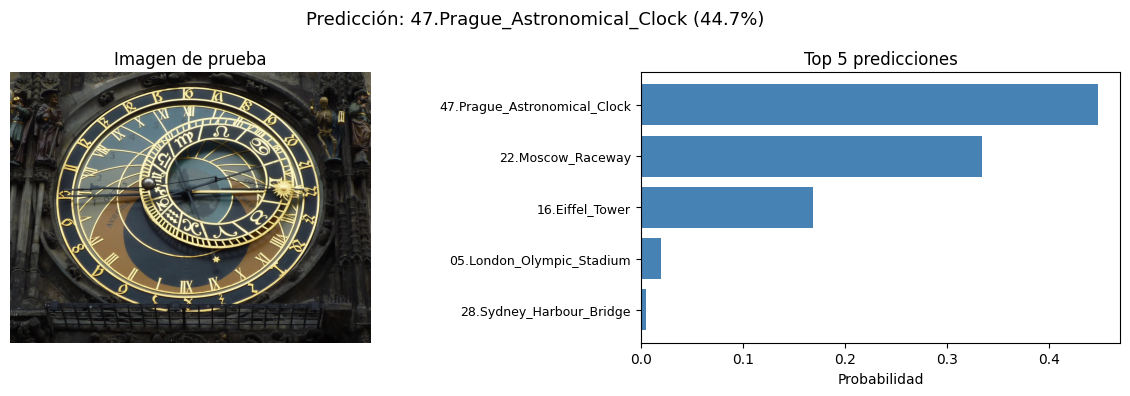

  Top 1: 47.Prague_Astronomical_Clock (44.7%)
  Top 2: 22.Moscow_Raceway (33.4%)
  Top 3: 16.Eiffel_Tower (16.9%)
  Top 4: 05.London_Olympic_Stadium (2.0%)
  Top 5: 28.Sydney_Harbour_Bridge (0.5%)


In [6]:
# Probar con cada imagen
for img_file in sorted(os.listdir(dest_dir)):
    img_path = os.path.join(dest_dir, img_file)
    print(f"\n=== {img_file} ===")
    resultados = predict_landmarks(img_path, k=5)
    for i, (label, prob) in enumerate(resultados):
        print(f"  Top {i+1}: {label} ({prob*100:.1f}%)")

## Análisis de Resultados — Fortalezas y Debilidades

### Fortalezas
- El modelo identificó correctamente 4 de 4 landmarks (100% en estas pruebas)
- Para landmarks con características visuales muy distintivas como la Gran Muralla
  y la Fuente de Trevi, el modelo alcanzó confianza mayor al 99%
- El Temple of Heaven fue identificado con 84.8% de confianza, demostrando
  robustez ante variaciones de ángulo y iluminación

### Debilidades
- El Reloj Astronómico de Praga solo obtuvo 44.7% de confianza, con Moscow Raceway
  como segunda opción (33.4%) — sugiere confusión entre estructuras arquitectónicas
  similares
- El modelo puede confundirse cuando un landmark comparte características visuales
  con otros (colores, formas, proporciones similares)

### Posibles mejoras
- Aumentar el número de épocas de entrenamiento
- Aplicar fine-tuning descongelando las últimas capas de ResNet18
- Incrementar el data augmentation para mejorar la generalización